In [35]:
!pip install ipython-sql prettytable --quiet
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [36]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

In [37]:
# Load dataset into pandas
import pandas as pd

df = pd.read_csv("u.data", sep="\t", names=["user_id", "movie_id", "rating", "timestamp"])
df.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [38]:
# Store data in SQLite database
import sqlite3

conn = sqlite3.connect("movies.db")
df.to_sql("ratings", conn, if_exists="replace", index=False)
conn.close()

In [39]:
%sql sqlite:///movies.db

In [40]:
# Average ratings
%%sql
SELECT AVG(rating) FROM ratings;

 * sqlite:///movies.db
Done.


AVG(rating)
3.52986


In [41]:
# Top 10 movies
%%sql
SELECT
    movie_id,
    COUNT(*) AS num_ratings
FROM ratings
GROUP BY movie_id
ORDER BY num_ratings DESC
LIMIT 10;

 * sqlite:///movies.db
Done.


movie_id,num_ratings
50,583
258,509
100,508
181,507
294,485
286,481
288,478
1,452
300,431
121,429


In [42]:
# Top 10 highest rated movies (min 100 ratings)
%%sql
SELECT
    movie_id,
    AVG(rating) AS avg_rating,
    COUNT(*) AS num_ratings
FROM ratings
GROUP BY movie_id
HAVING COUNT(*) >= 100
ORDER BY avg_rating DESC
LIMIT 10;

 * sqlite:///movies.db
Done.


movie_id,avg_rating,num_ratings
408,4.491071428571429,112
318,4.466442953020135,298
169,4.466101694915254,118
483,4.45679012345679,243
64,4.445229681978798,283
603,4.3875598086124405,209
12,4.385767790262173,267
50,4.3584905660377355,583
178,4.344,125
134,4.292929292929293,198


In [43]:
# Most active users
%%sql
SELECT
    user_id,
    COUNT(*) AS total_ratings
FROM ratings
GROUP BY user_id
ORDER BY total_ratings DESC
LIMIT 10;

 * sqlite:///movies.db
Done.


user_id,total_ratings
405,737
655,685
13,636
450,540
276,518
416,493
537,490
303,484
234,480
393,448


In [44]:
# Rating distribution
%%sql
SELECT
    rating,
    COUNT(*) AS count
FROM ratings
GROUP BY rating
ORDER BY rating;

 * sqlite:///movies.db
Done.


rating,count
1,6110
2,11370
3,27145
4,34174
5,21201


In [45]:
# Average rating per user
%%sql
SELECT
    user_id,
    AVG(rating) AS avg_rating,
    COUNT(*) AS total_ratings
FROM ratings
GROUP BY user_id
ORDER BY avg_rating DESC
LIMIT 10;

 * sqlite:///movies.db
Done.


user_id,avg_rating,total_ratings
849,4.869565217391305,23
688,4.833333333333333,24
507,4.724137931034483,58
628,4.703703703703703,27
928,4.6875,32
118,4.661971830985915,71
907,4.571428571428571,147
686,4.563380281690141,71
427,4.548387096774194,31
565,4.542857142857143,35


In [46]:
# Movies with consistent ratings
%%sql
SELECT
    movie_id,
    AVG(rating) AS avg_rating,
    (AVG(rating * rating) - AVG(rating)*AVG(rating)) AS variance,
    COUNT(*) AS num_ratings
FROM ratings
GROUP BY movie_id
HAVING COUNT(*) >= 100
ORDER BY variance ASC
LIMIT 10;

 * sqlite:///movies.db
Done.


movie_id,avg_rating,variance,num_ratings
479,4.251396648044692,0.4675259823351361,179
603,4.3875598086124405,0.5052997870927847,209
480,4.284916201117318,0.5054149371118264,179
178,4.344,0.5136639999999986,125
483,4.45679012345679,0.5279682975156206,243
427,4.292237442922374,0.5447342632555632,219
498,4.184210526315789,0.5713296398891963,152
484,4.2101449275362315,0.5717811384163021,138
657,4.259541984732825,0.5738593322067445,131
193,3.917197452229299,0.5855004259807721,157


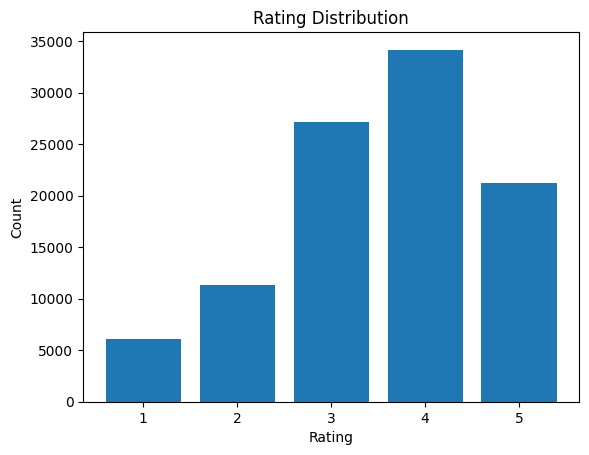

In [47]:
# Visualization: rating distribution
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df_plot = pd.read_sql_query("""
SELECT rating, COUNT(*) as count
FROM ratings
GROUP BY rating
""", sqlite3.connect("movies.db"))

plt.bar(df_plot['rating'], df_plot['count'])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()